# 01 - Data Exploration

Explore the training dataset for the LSS embedding model.
Understand label distributions, sentence lengths, and data quality.

In [ ]:
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

dataset = load_dataset("sentence-transformers/all-nli", "pair", split="train")
print(f"Dataset size: {len(dataset)}")
print(f"Columns: {dataset.column_names}")
dataset[0]

pair/train-00000-of-00001.parquet:   0%|          | 0.00/26.2M [00:00<?, ?B/s]

pair/dev-00000-of-00001.parquet:   0%|          | 0.00/645k [00:00<?, ?B/s]

pair/test-00000-of-00001.parquet:   0%|          | 0.00/666k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/314315 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/6808 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6831 [00:00<?, ? examples/s]

Dataset size: 314315
Columns: ['anchor', 'positive']


{'anchor': 'A person on a horse jumps over a broken down airplane.',
 'positive': 'A person is outdoors, on a horse.'}

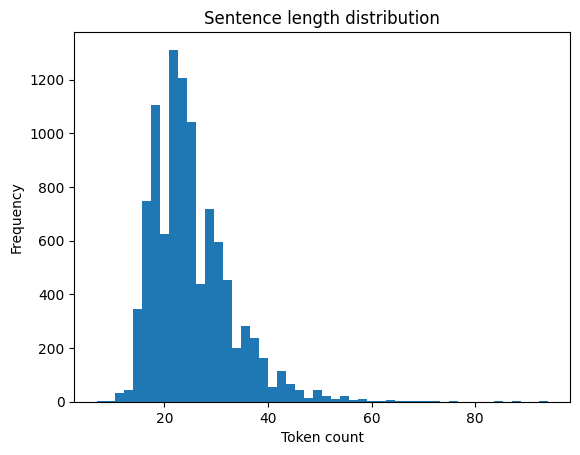

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

lengths = []
for i in range(min(10000, len(dataset))):
    tokens = tokenizer.encode(dataset[i]["anchor"], dataset[i]["positive"], add_special_tokens=True)
    lengths.append(len(tokens))

plt.hist(lengths, bins=50)
plt.title("Sentence length distribution")
plt.xlabel("Token count")
plt.ylabel("Frequency")

plt.show()